In [1]:
# Task : Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Task : Load Dataset

df = pd.read_excel("glass.xlsx",sheet_name="glass")

print(df.head())

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


In [3]:
# Task : Display Dataset Information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None


In [4]:
# Task : Statistical Summary

print(df.describe())

               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe        Type  
count  214.000000  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009    2.780374  
std      1.423153    0.497219    0.097439    2.103739  
min      5.430000    0.000000    0.000000    1

In [5]:
# Task : Check Missing Values

print(df.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


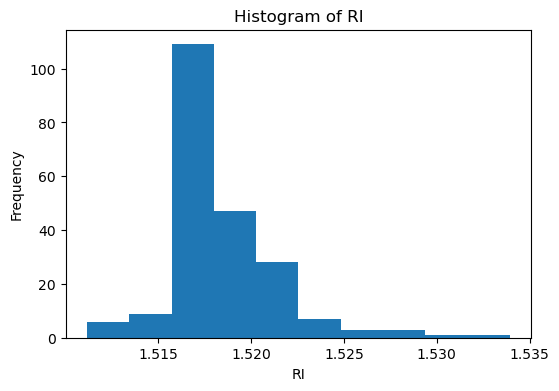

In [6]:
# Task : Histogram

numeric_column = df.select_dtypes(include=np.number).columns[0]

plt.figure(figsize=(6,4))

plt.hist(df[numeric_column], bins=10)

plt.title(f"Histogram of {numeric_column}")
plt.xlabel(numeric_column)
plt.ylabel("Frequency")

plt.show()

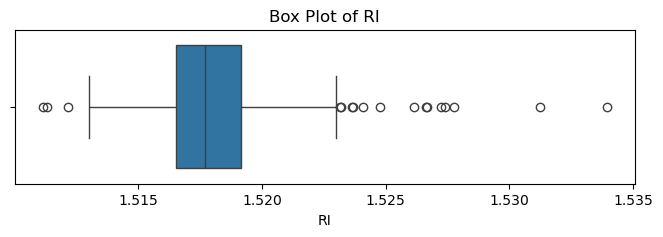

In [7]:
# Task : Box Plot

numeric_column = df.select_dtypes(include=np.number).columns[0]

plt.figure(figsize=(8,2))

sns.boxplot(x=df[numeric_column])

plt.title(f"Box Plot of {numeric_column}")

plt.show()

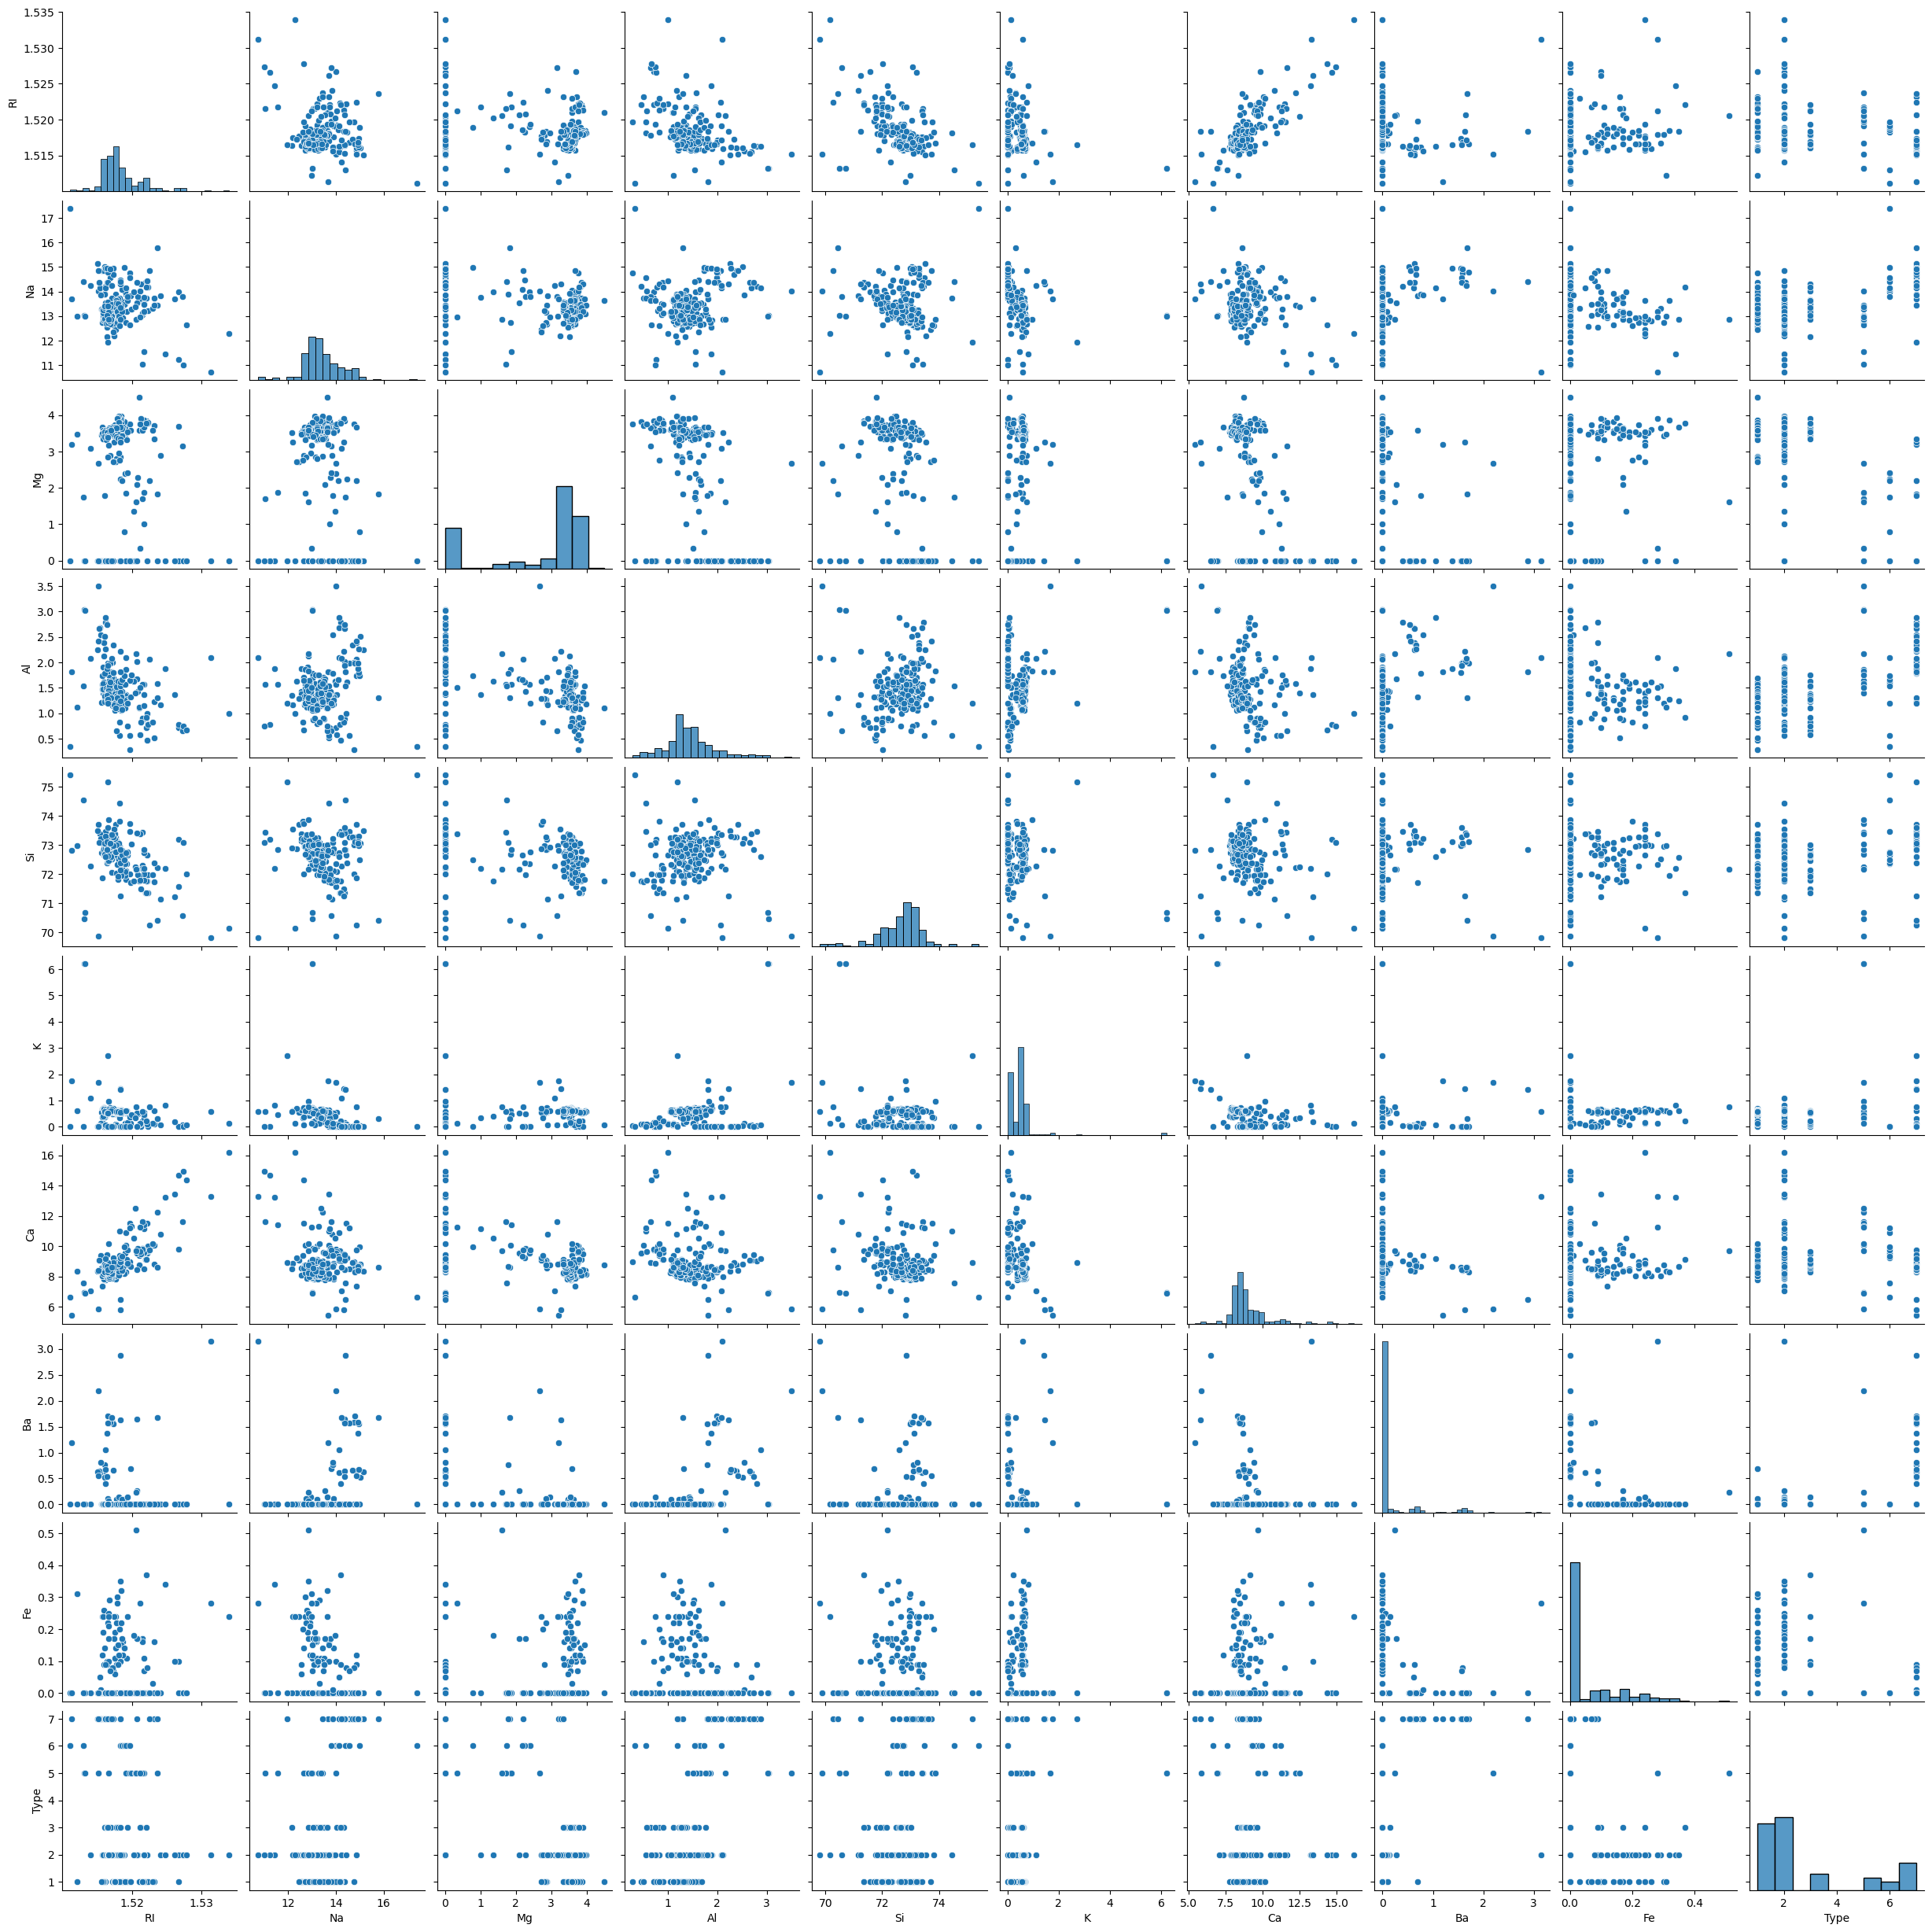

In [8]:
# Task: Pair Plot

import seaborn as sns

sns.pairplot(df)
plt.show()

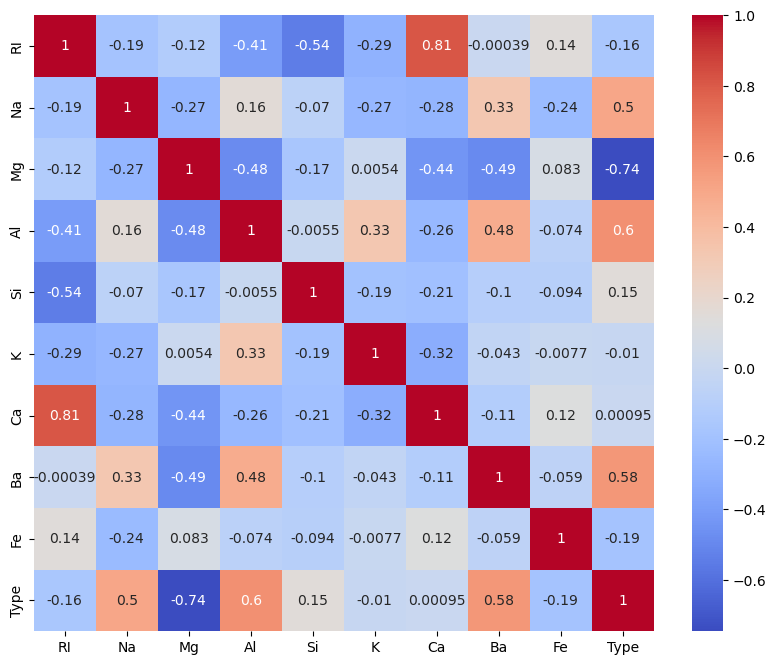

In [9]:
# Task: Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [10]:
# Task : Handle Missing Values

df = df.fillna(df.mean(numeric_only=True))

print(df.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [11]:
# Task : Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


In [12]:
# Task : Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

target_column = df.columns[-1]

feature_columns = df.drop(columns=[target_column]).columns

df[feature_columns] = scaler.fit_transform(df[feature_columns])

print(df.head())

         RI        Na        Mg        Al        Si         K        Ca  \
0  0.872868  0.284953  1.254639 -0.692442 -1.127082 -0.671705 -0.145766   
1 -0.249333  0.591817  0.636168 -0.170460  0.102319 -0.026213 -0.793734   
2 -0.721318  0.149933  0.601422  0.190912  0.438787 -0.164533 -0.828949   
3 -0.232831 -0.242853  0.698710 -0.310994 -0.052974  0.112107 -0.519052   
4 -0.312045 -0.169205  0.650066 -0.411375  0.555256  0.081369 -0.624699   

         Ba        Fe  Type  
0 -0.352877 -0.586451     1  
1 -0.352877 -0.586451     1  
2 -0.352877 -0.586451     1  
3 -0.352877 -0.586451     1  
4 -0.352877 -0.586451     1  


In [13]:
# Task : Define Features and Target Variable

target_column = df.columns[-1]

X = df.drop(columns=[target_column])

y = df[target_column]

print(X.head())

print(y.head())

         RI        Na        Mg        Al        Si         K        Ca  \
0  0.872868  0.284953  1.254639 -0.692442 -1.127082 -0.671705 -0.145766   
1 -0.249333  0.591817  0.636168 -0.170460  0.102319 -0.026213 -0.793734   
2 -0.721318  0.149933  0.601422  0.190912  0.438787 -0.164533 -0.828949   
3 -0.232831 -0.242853  0.698710 -0.310994 -0.052974  0.112107 -0.519052   
4 -0.312045 -0.169205  0.650066 -0.411375  0.555256  0.081369 -0.624699   

         Ba        Fe  
0 -0.352877 -0.586451  
1 -0.352877 -0.586451  
2 -0.352877 -0.586451  
3 -0.352877 -0.586451  
4 -0.352877 -0.586451  
0    1
1    1
2    1
3    1
4    1
Name: Type, dtype: int64


In [14]:
# Task : Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(171, 9)
(43, 9)


In [15]:
# Task : Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

print("Random Forest Model Training Completed")

Random Forest Model Training Completed


In [16]:
# Task : Predict Testing Data

y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[1 7 1 7 2 2 1 2 2 2]


In [17]:
# Task : Evaluate Model Performance

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='weighted')

recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9069767441860465
Precision: 0.9149274498111707
Recall: 0.9069767441860465
F1 Score: 0.9043200225826764


In [18]:
# Task : Bagging Method

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)

bagging_accuracy = accuracy_score(y_test, bagging_pred)

print("Bagging Accuracy:", bagging_accuracy)

Bagging Accuracy: 0.8604651162790697


In [19]:
# Task : Boosting Method

from sklearn.ensemble import AdaBoostClassifier

boosting_model = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

boosting_model.fit(X_train, y_train)

boosting_pred = boosting_model.predict(X_test)

boosting_accuracy = accuracy_score(y_test, boosting_pred)

print("Boosting Accuracy:", boosting_accuracy)

Boosting Accuracy: 0.5348837209302325


In [20]:
# Task : Compare Results

print("Random Forest Accuracy:", accuracy)

print("Bagging Accuracy:", bagging_accuracy)

print("Boosting Accuracy:", boosting_accuracy)

Random Forest Accuracy: 0.9069767441860465
Bagging Accuracy: 0.8604651162790697
Boosting Accuracy: 0.5348837209302325


In [21]:
# Task : Explain Bagging and Boosting

print("Bagging combines multiple models trained independently to reduce variance.")

print("Boosting trains models sequentially to correct previous errors and improve performance.")

print("Bagging reduces overfitting while Boosting improves weak learners.")

Bagging combines multiple models trained independently to reduce variance.
Boosting trains models sequentially to correct previous errors and improve performance.
Bagging reduces overfitting while Boosting improves weak learners.


In [22]:
# Task : Handling Imbalanced Data

print("Imbalanced data can be handled using oversampling, undersampling, or SMOTE techniques.")

print("These methods help improve model performance for minority classes.")

Imbalanced data can be handled using oversampling, undersampling, or SMOTE techniques.
These methods help improve model performance for minority classes.
